# MedLayBench-V — Dataset Tutorial

End-to-end walkthrough for the **MedLayBench-V** dataset:

1. Load the dataset from Hugging Face
2. Inspect the schema and one example
3. Visualize a few image / expert / lay triples
4. Compute simple readability statistics on Expert vs. Layman captions
5. Run zero-shot text-to-image retrieval with a CLIP-style model

Project page: <https://janghana.github.io/MedLayBench-V/>  
Hugging Face: <https://huggingface.co/datasets/hanjang/MedLayBench-V>

## 1. Load the dataset

In [ ]:
# install
# !pip install -q datasets transformers pillow textstat matplotlib open_clip_torch tqdm

In [2]:
from datasets import load_dataset

ds = load_dataset("hanjang/MedLayBench-V")
print(ds)

/data2/hjang/.conda/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DatasetDict({
    train: Dataset({
        features: ['image', 'cuis', 'expert_caption', 'layman_caption'],
        num_rows: 59962
    })
    validation: Dataset({
        features: ['image', 'cuis', 'expert_caption', 'layman_caption'],
        num_rows: 9904
    })
    test: Dataset({
        features: ['image', 'cuis', 'expert_caption', 'layman_caption'],
        num_rows: 9927
    })
})


## 2. Inspect the schema

In [3]:
# fields
ex = ds["test"][0]
for k, v in ex.items():
    if k == "image":
        print(k, type(v).__name__)
    else:
        print(k, repr(v)[:200])

image PngImageFile
cuis "['C0040405']"
expert_caption 'CT chest axial view showing a huge ascending aortic aneurysm (*).'
layman_caption 'The CT scan of the chest shows a large bulge in the upper part of the aorta.'


Each example contains:

| field         | type   | description                          |
|---------------|--------|--------------------------------------|
| `image_id`    | str    | unique id (`ROCOv2_<year>_<split>_<n>`) |
| `image`       | PIL    | medical image                        |
| `cuis`        | str    | list-encoded UMLS CUIs (MedCAT)      |
| `expert_caption` | str | expert caption $T_{exp}$             |
| `layman_caption` | str | SCGR-refined lay caption $T_{lay}$   |

## 3. Visualize a few examples

[sample_0]
  Expert : CT chest axial view showing a huge ascending aortic aneurysm (*).
  Layman : The CT scan of the chest shows a large bulge in the upper part of the aorta.

[sample_1]
  Expert : Computed tomography (CT) shows floating thrombosis (white arrow)
  Layman : Computed tomography (CT) shows a blood clot (white arrow).

[sample_2]
  Expert : Digitally subtracted angiogram demonstrates active extravasation of the superior rectal artery into the ileal-conduit (blue arrow)
  Layman : The digitally subtracted angiogram shows active bleeding from the superior rectal artery into the ileal-conduit (blue arrow).

[sample_3]
  Expert : Digitally subtracted angiogram of the IMA demonstrated cessation of flow through the proximal superior rectal artery in the region of the intersection between the artery and ureter with retained perfusion of the rectosigmoid region and resolution of active extravasation
  Layman : The scan shows a blockage of blood flow through the upper part of the 

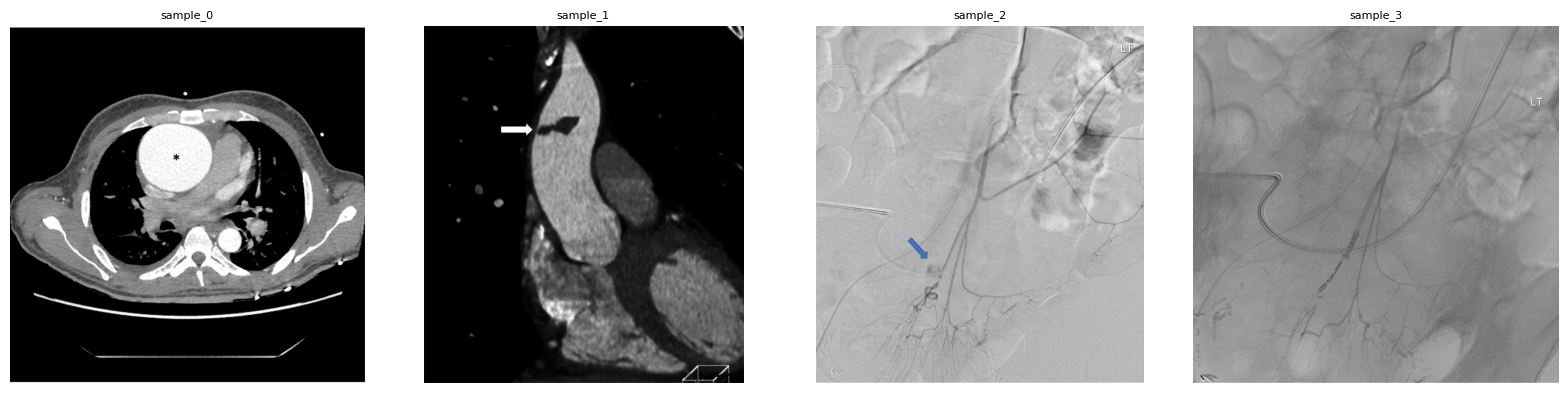

In [4]:
import matplotlib.pyplot as plt

N = 4
fig, axes = plt.subplots(1, N, figsize=(4*N, 4))
for i, ax in enumerate(axes):
    ex = ds["test"][i]
    ax.imshow(ex["image"], cmap="gray")
    ax.set_title(f"sample_{i}", fontsize=8)
    ax.axis("off")
    print(f"[sample_{i}]")
    print("  Expert :", ex["expert_caption"])
    print("  Layman :", ex["layman_caption"])
    print()
plt.tight_layout(); plt.show()

## 4. Readability: Expert vs. Layman

In [5]:
from tqdm import tqdm
import textstat, statistics

def fkgl(texts):
    return statistics.mean(textstat.flesch_kincaid_grade(t) for t in tqdm(texts, desc="FKGL") if t)

sample = ds["test"].select(range(500))
exp = [ex["expert_caption"] for ex in tqdm(sample, desc="Loading")]
lay = [ex["layman_caption"] for ex in sample]
print(f"FKGL Expert : {fkgl(exp):.2f}")
print(f"FKGL Layman : {fkgl(lay):.2f}")

FKGL: 100%|██████████| 500/500 [00:00<00:00, 889.08it/s]


FKGL Expert : 13.38


FKGL: 100%|██████████| 500/500 [00:00<00:00, 32065.56it/s]

FKGL Layman : 10.53


## 5. Zero-shot retrieval (OpenCLIP example)

In [6]:
import torch
from open_clip import create_model_from_pretrained, get_tokenizer

model, preprocess = create_model_from_pretrained("hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224")
tokenizer = get_tokenizer("hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224")
model.eval()

subset = ds["test"].select(range(64))
imgs = torch.stack([preprocess(ex["image"].convert("RGB")) for ex in subset])
texts = tokenizer([ex["layman_caption"] for ex in subset], context_length=256)

with torch.no_grad():
    img_e = model.encode_image(imgs)
    txt_e = model.encode_text(texts)
    img_e = img_e / img_e.norm(dim=-1, keepdim=True)
    txt_e = txt_e / txt_e.norm(dim=-1, keepdim=True)
    sims = img_e @ txt_e.T

rank = sims.argsort(dim=1, descending=True)
r1 = (rank[:, 0] == torch.arange(len(subset))).float().mean().item()
print(f"R@1 (text->image, lay captions): {r1:.3f}")

R@1 (text->image, lay captions): 0.688


## Citation

```bibtex
@misc{jang2026medlaybenchvlargescalebenchmarkexpertlay,
      title={MedLayBench-V: A Large-Scale Benchmark for Expert-Lay Semantic Alignment in Medical Vision Language Models}, 
      author={Han Jang and Junhyeok Lee and Heeseong Eum and Kyu Sung Choi},
      year={2026},
      eprint={2604.05738},
      archivePrefix={arXiv},
      primaryClass={cs.CL},
      url={https://arxiv.org/abs/2604.05738}, 
}
```